✅ Libraries imported successfully.
=== DATASET SHAPE ===
Rows: 50,000  |  Columns: 10

=== FIRST 5 ROWS ===
  Order_ID Customer_Region Product_Category  Order_Date  Ship_Date  \
0  OR10000            West             Home   5/12/2024  5/16/2024   
1  OR10001         Central             Home   4/19/2025  4/24/2025   
2  OR10002            East             Home    7/2/2025   7/4/2025   
3  OR10003         Central          Grocery   10/4/2025  10/8/2025   
4  OR10004         Central           Sports  10/31/2023  11/2/2023   

  Delivery_Date Shipping_Mode  Shipping_Cost Delivery_Status  Delivery_Days  
0     5/26/2024      Standard            122       Delivered             10  
1     4/26/2025      Standard            143       Delivered              2  
2     7/11/2025      Standard            107         Delayed              7  
3    10/16/2025      Standard            145         Delayed              8  
4     11/7/2023      Standard            121       Delivered              5  
===

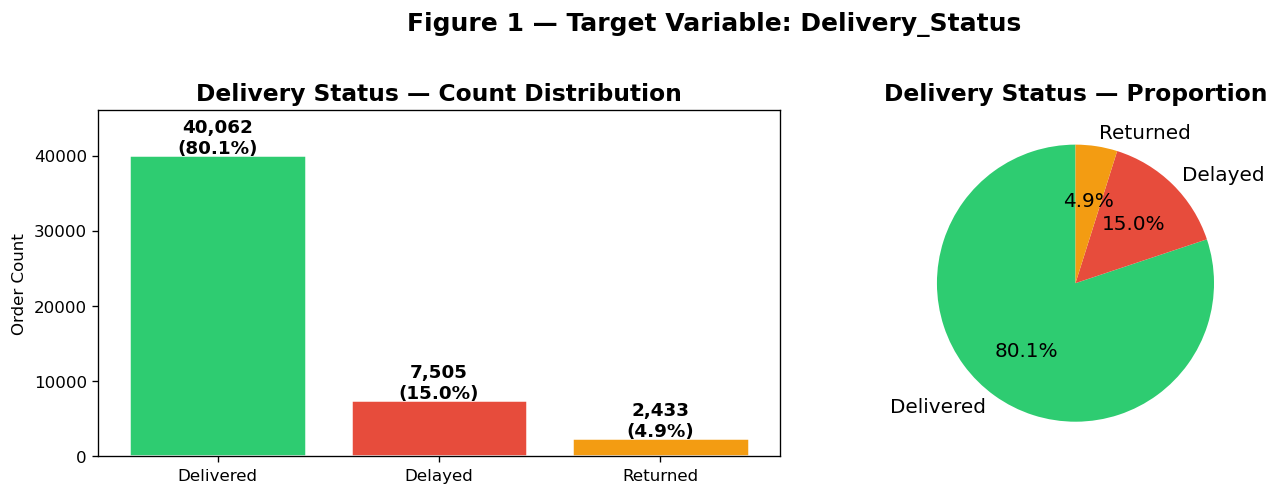


Class counts:
                 count  Percentage %
Delivery_Status                     
Delivered        40062          80.1
Delayed           7505          15.0
Returned          2433           4.9


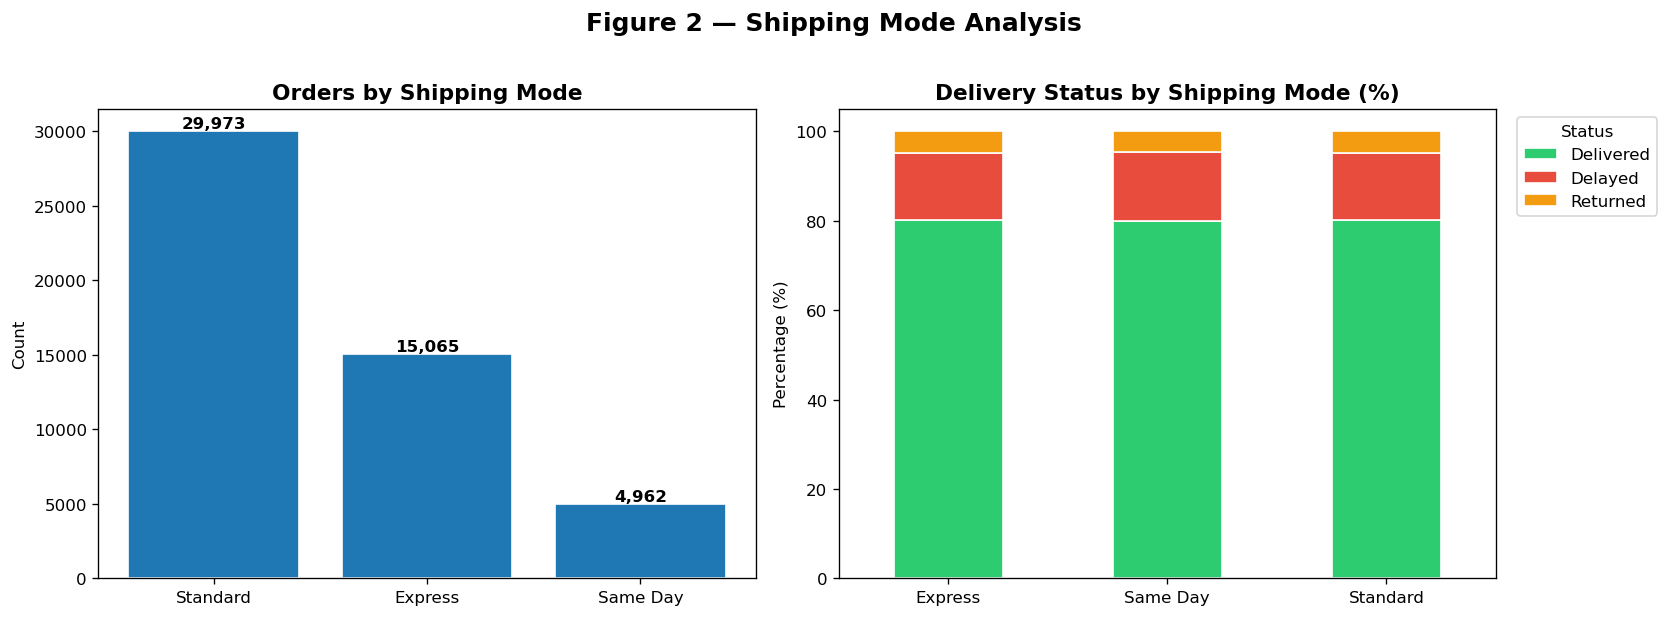

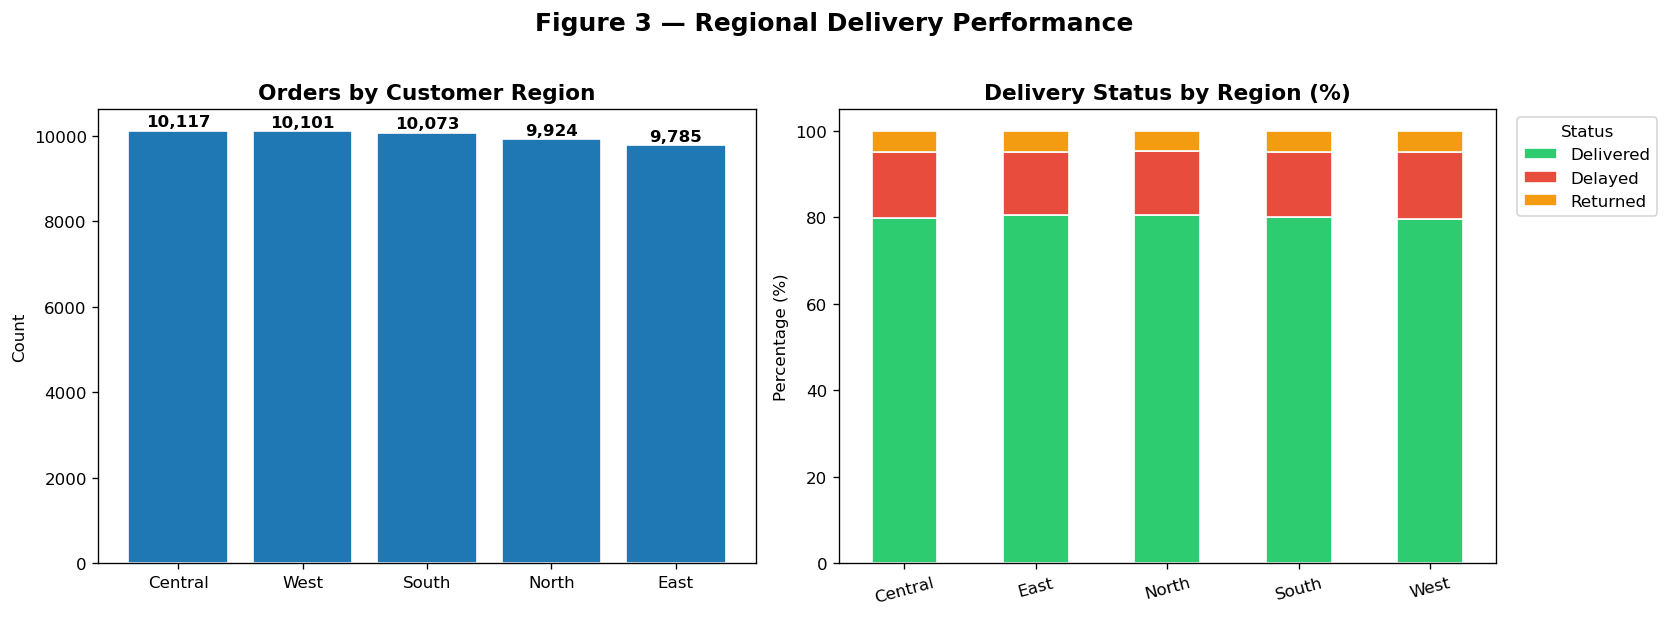

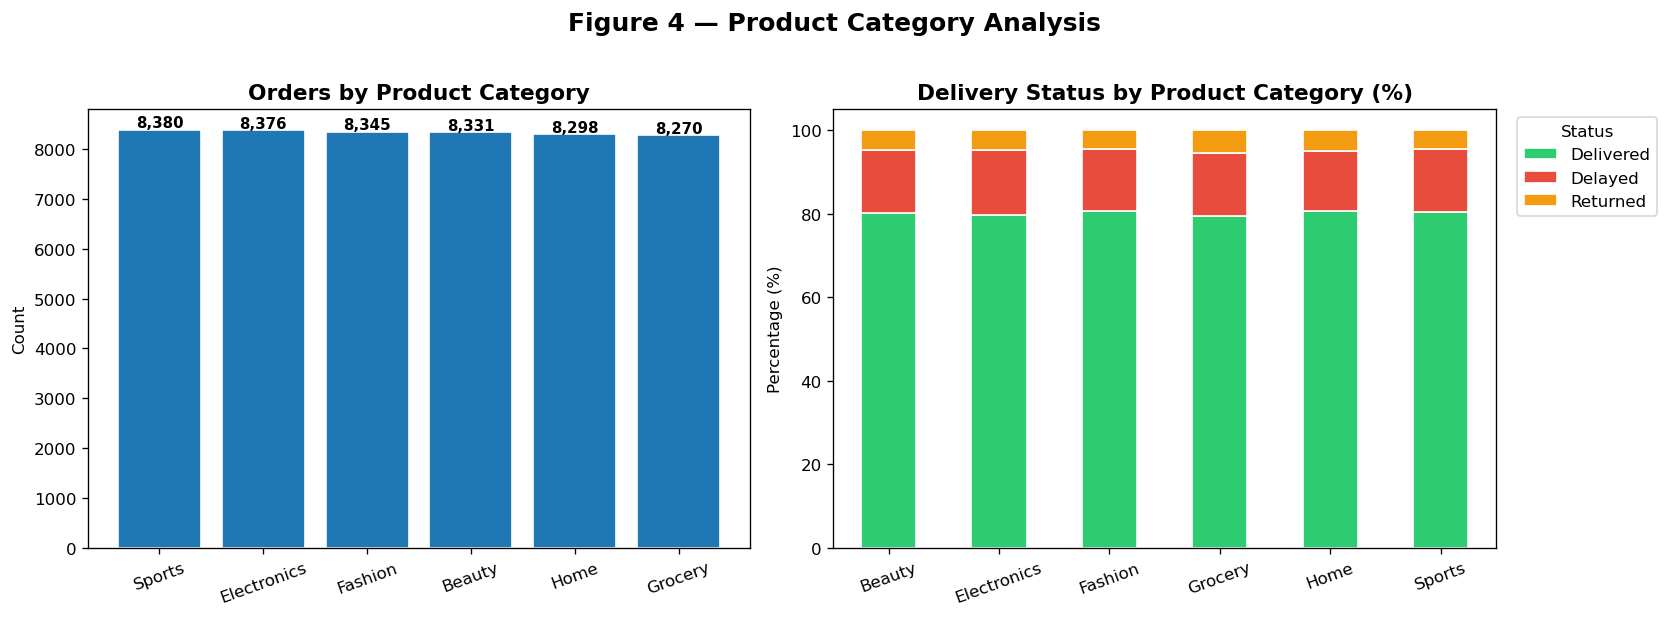

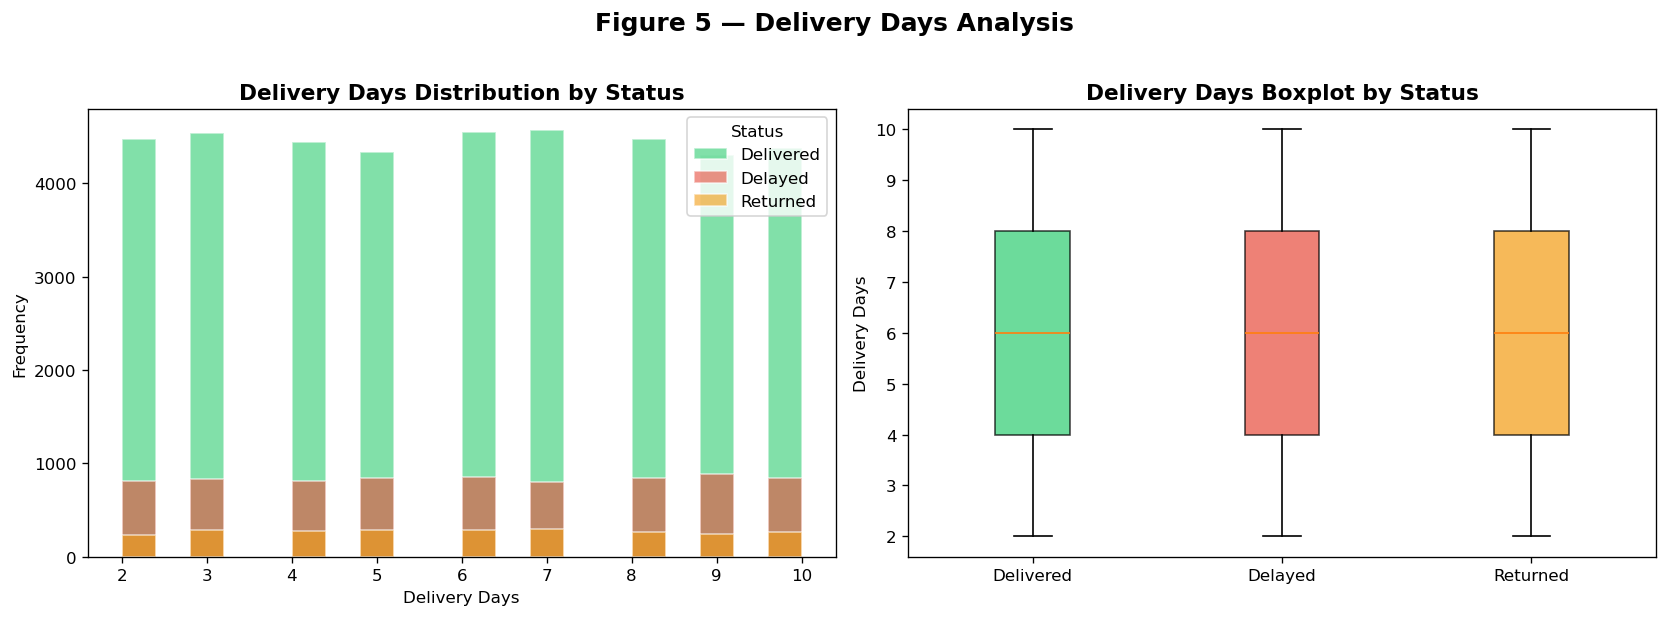


Delivery Days — Mean by Status:
Delivery_Status
Delayed      6.04
Delivered    5.98
Returned     5.98
Name: Delivery_Days, dtype: float64


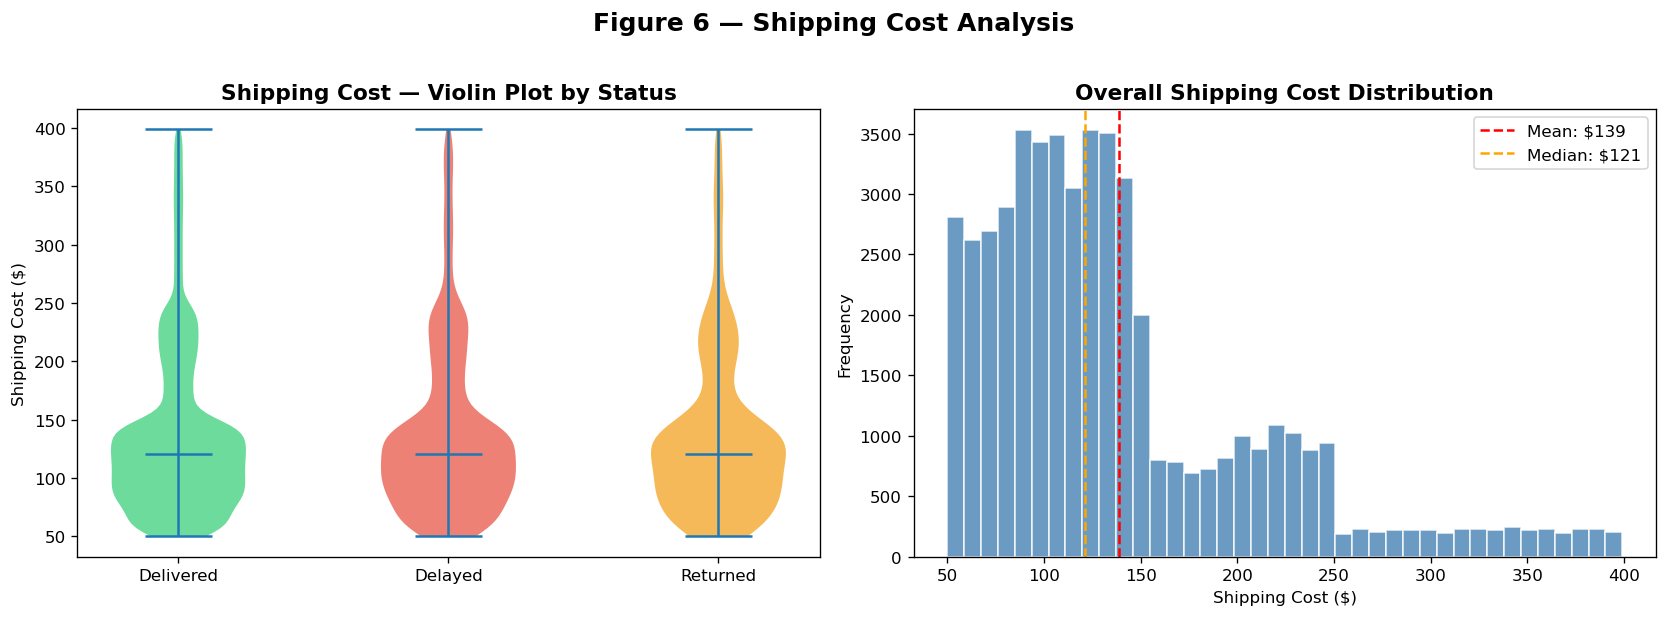


Shipping Cost — Mean by Status:
Delivery_Status
Delayed      139.87
Delivered    138.68
Returned     138.26
Name: Shipping_Cost, dtype: float64


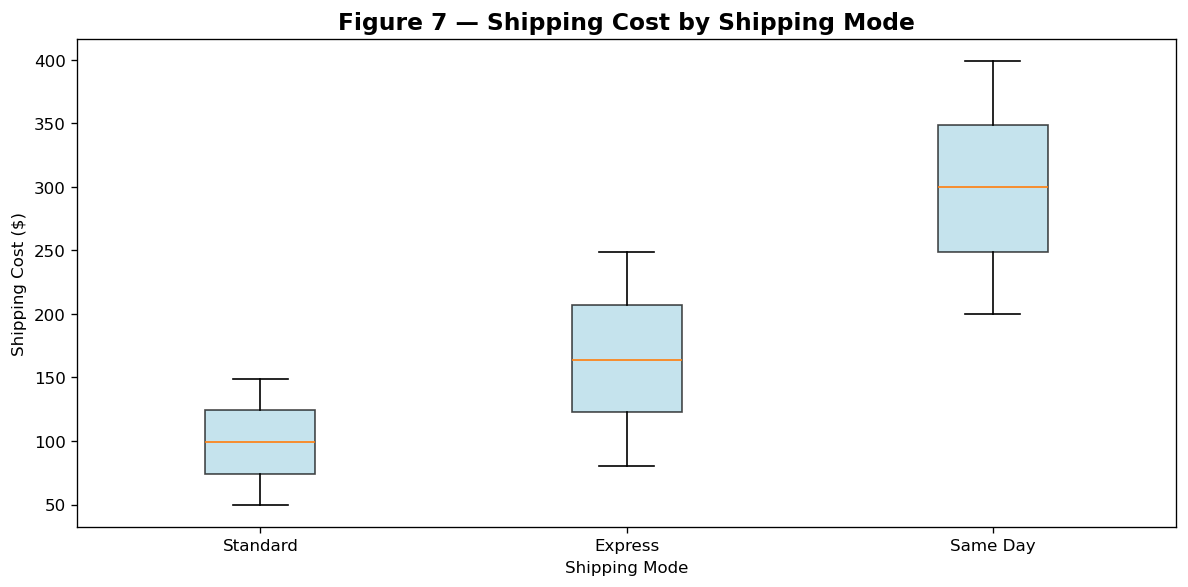

Mean Shipping Cost by Mode:
Shipping_Mode
Express     164.58
Same Day    299.59
Standard     99.29
Name: Shipping_Cost, dtype: float64


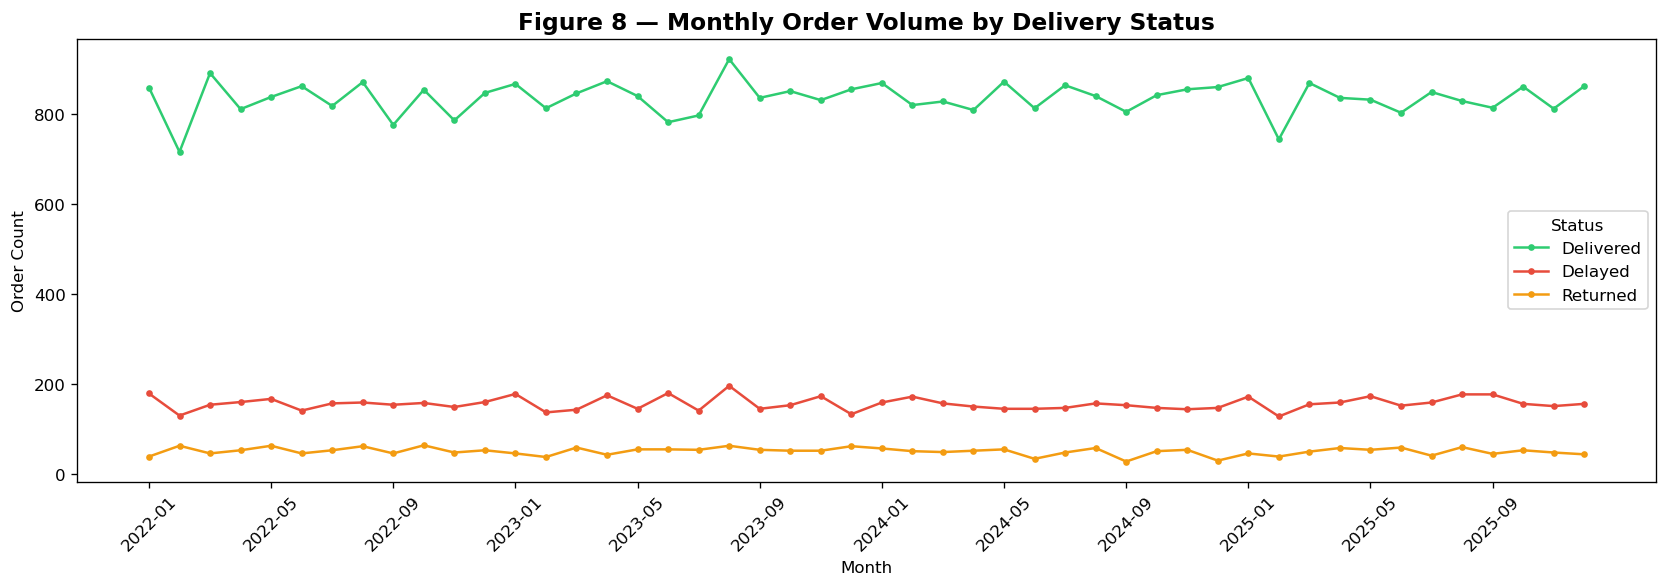

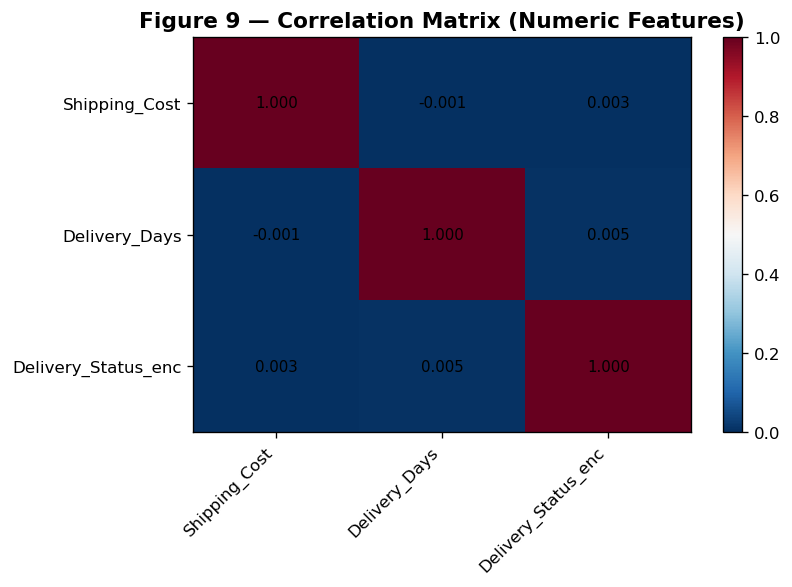

Correlation with Delivery_Status (encoded):
Shipping_Cost    0.003
Delivery_Days    0.005
Name: Delivery_Status_enc, dtype: float64
=== OUTLIER DETECTION (IQR Method) ===
Shipping_Cost       :  3013 outliers (6.03%) | IQR fence: [-26.0, 278.0]
Delivery_Days       :     0 outliers (0.00%) | IQR fence: [-2.0, 14.0]


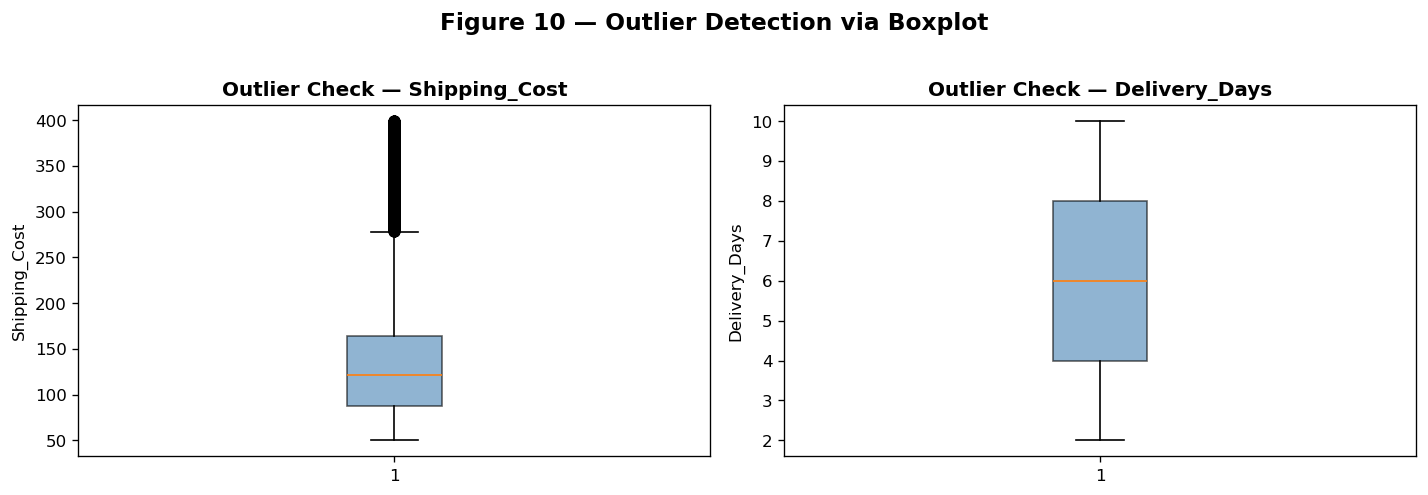

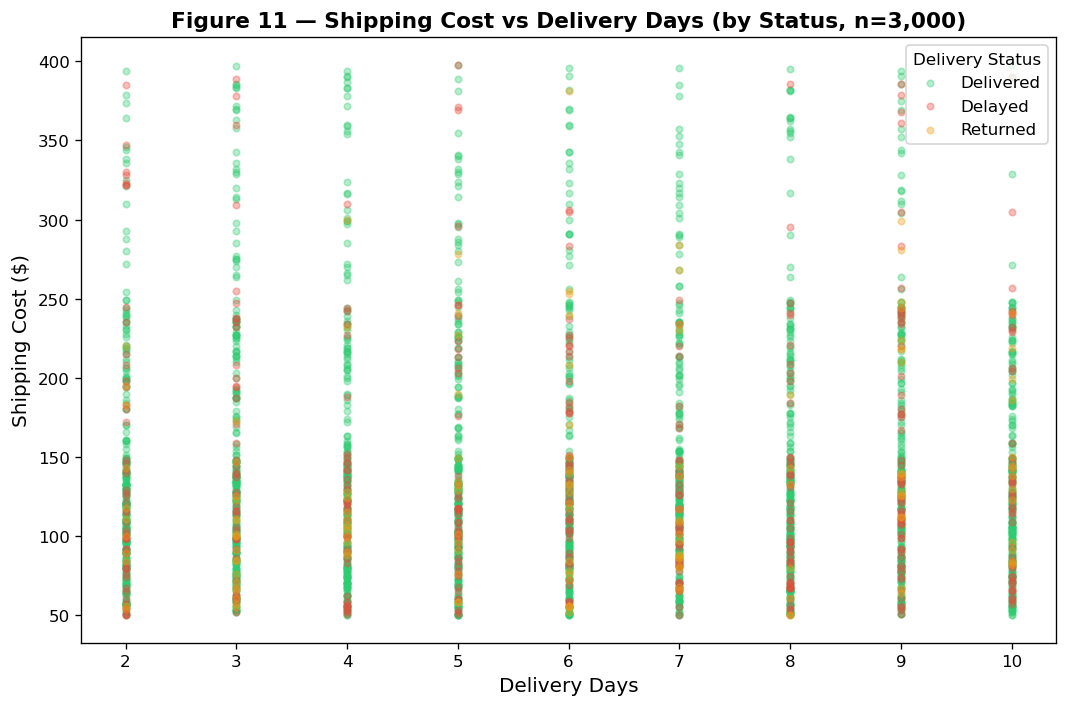

Date columns parsed successfully:
Order_Date       datetime64[ns]
Ship_Date        datetime64[ns]
Delivery_Date    datetime64[ns]
dtype: object
Order_ID removed. Remaining columns:
['Customer_Region', 'Product_Category', 'Order_Date', 'Ship_Date', 'Delivery_Date', 'Shipping_Mode', 'Shipping_Cost', 'Delivery_Status', 'Delivery_Days', 'Order_Date_dt', 'YearMonth']
Customer_Region      → classes: ['Central', 'East', 'North', 'South', 'West']
Product_Category     → classes: ['Beauty', 'Electronics', 'Fashion', 'Grocery', 'Home', 'Sports']
Shipping_Mode        → classes: ['Express', 'Same Day', 'Standard']

Target classes: ['Delayed', 'Delivered', 'Returned']
Target mapping: {'Delayed': np.int32(0), 'Delivered': np.int32(1), 'Returned': np.int32(2)}
Columns after initial preprocessing:
['Customer_Region', 'Product_Category', 'Order_Date', 'Ship_Date', 'Delivery_Date', 'Shipping_Mode', 'Shipping_Cost', 'Delivery_Status', 'Delivery_Days', 'Customer_Region_enc', 'Product_Category_enc', 'Shippi

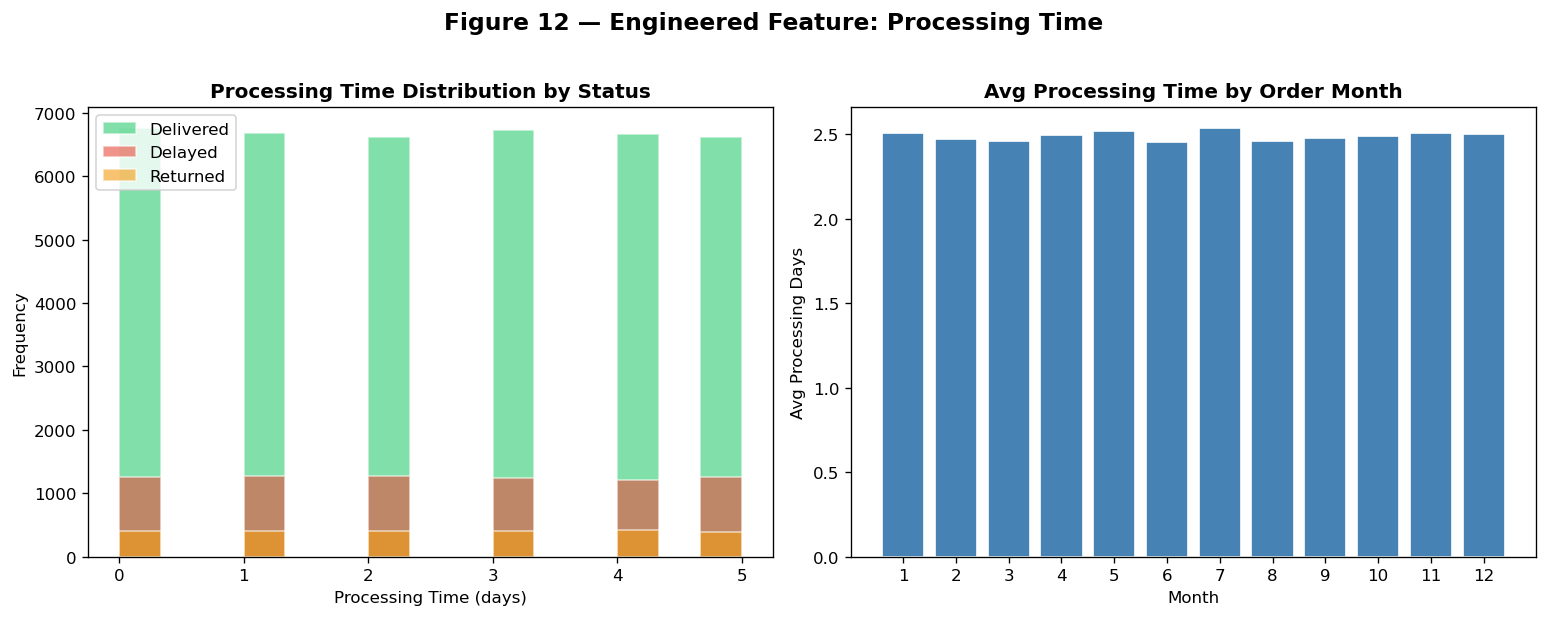

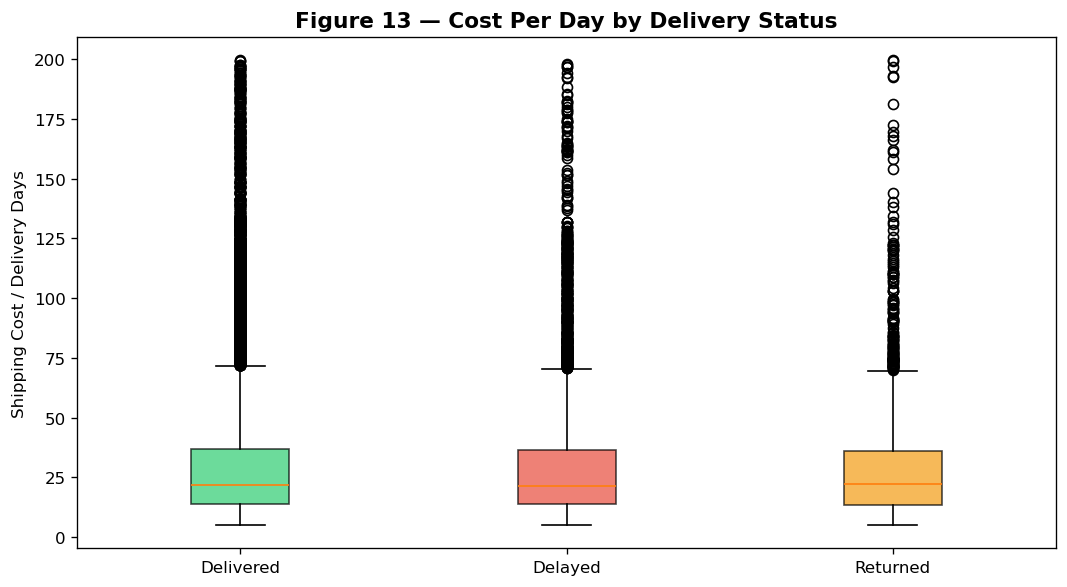

Feature matrix shape: (50000, 25)
Target vector shape: (50000,)
Class distribution: {0: np.int64(7505), 1: np.int64(40062), 2: np.int64(2433)}

Target mapping: {np.int32(0): 'Delayed', np.int32(1): 'Delivered', np.int32(2): 'Returned'}


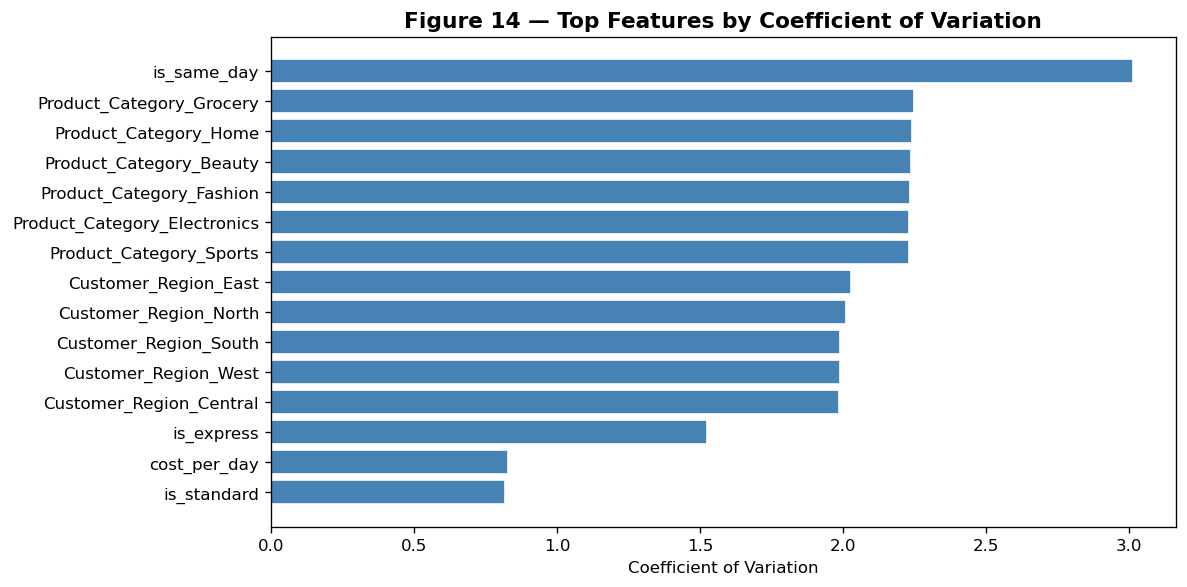

Feature scaling complete.
Mean of scaled features (should ≈ 0): 0.000000
Std of scaled features (should ≈ 1): 1.000010
Train set: 40,000 samples (80.0%)
Test set:  10,000 samples (20.0%)

Class distribution — Train:
target
0     6004
1    32050
2     1946
Name: count, dtype: int64

Class distribution — Test:
target
0    1501
1    8012
2     487
Name: count, dtype: int64
✅ Preprocessed data saved:
   → X_train.csv, X_test.csv, y_train.csv, y_test.csv
   → feature_columns.json

Phase 2 is ready to begin!


In [4]:
# ============================================================
# CELL 1 — Import all required libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import warnings
import json
import os

warnings.filterwarnings('ignore')

plt.style.use('default')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

PALETTE = {
    'Delivered': '#2ecc71',
    'Delayed': '#e74c3c',
    'Returned': '#f39c12'
}

print('✅ Libraries imported successfully.')

# ============================================================
# CELL 2 — Load the dataset and inspect basic structure
# ============================================================
df = pd.read_csv('E-Commerce Order Fulfillment Dataset (50K Records).csv')

print('=== DATASET SHAPE ===')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')

print('\n=== FIRST 5 ROWS ===')
print(df.head())

# ============================================================
# CELL 3 — Column data types and memory usage
# ============================================================
print('=== COLUMN INFO ===')
print(df.info())

print('\n=== DATA TYPES SUMMARY ===')
print(df.dtypes.value_counts())

# ============================================================
# CELL 4 — Missing values check
# ============================================================
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

print('=== MISSING VALUES ===')
print(missing_df)

if missing.sum() == 0:
    print(f'\n✅ Total missing cells: {missing.sum()} — Dataset is COMPLETE.')
else:
    print(f'\n⚠️ Total missing cells: {missing.sum()}')

# ============================================================
# CELL 5 — Duplicate rows check
# ============================================================
dup_count = df.duplicated().sum()
print(f'Duplicate rows: {dup_count}')

if 'Order_ID' in df.columns:
    print(f'Unique Order_IDs: {df["Order_ID"].nunique():,} out of {len(df):,} rows')
    if df["Order_ID"].nunique() == len(df):
        print('✅ All Order_IDs are unique — no duplicate orders.')
    else:
        print('⚠️ Some Order_ID values are duplicated.')

# ============================================================
# CELL 6 — Statistical summary of numeric columns
# ============================================================
print('=== NUMERIC COLUMNS — DESCRIPTIVE STATISTICS ===')
print(df.describe().round(2))

# ============================================================
# CELL 7 — Categorical column cardinality overview
# ============================================================
cat_cols = df.select_dtypes(include='object').columns.tolist()

print('=== CATEGORICAL COLUMNS ===')
for col in cat_cols:
    vals = df[col].unique()
    print(f'{col:20s} → {df[col].nunique()} unique: {list(vals)[:8]}')

# ============================================================
# CELL 8 — EDA 1: Target class distribution
# ============================================================
status_counts = df['Delivery_Status'].value_counts()
status_pct = (status_counts / len(df) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = [PALETTE[s] for s in status_counts.index]

axes[0].bar(status_counts.index, status_counts.values, color=colors, edgecolor='white', linewidth=1.5)
for i, (v, p) in enumerate(zip(status_counts.values, status_pct.values)):
    axes[0].text(i, v + 200, f'{v:,}\n({p}%)', ha='center', fontsize=11, fontweight='bold')

axes[0].set_title('Delivery Status — Count Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Order Count')
axes[0].set_ylim(0, max(status_counts.values) * 1.15)

axes[1].pie(
    status_counts.values,
    labels=status_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 12}
)
axes[1].set_title('Delivery Status — Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Figure 1 — Target Variable: Delivery_Status', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_target_distribution.png', bbox_inches='tight')
plt.show()

print('\nClass counts:')
print(pd.concat([status_counts, status_pct.rename('Percentage %')], axis=1))

# ============================================================
# CELL 9 — EDA 2: Shipping Mode distribution & vs target
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mode_counts = df['Shipping_Mode'].value_counts()
axes[0].bar(mode_counts.index, mode_counts.values, edgecolor='white')
for i, v in enumerate(mode_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')
axes[0].set_title('Orders by Shipping Mode', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')

cross = pd.crosstab(df['Shipping_Mode'], df['Delivery_Status'], normalize='index') * 100
cross = cross[['Delivered', 'Delayed', 'Returned']]
cross.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=[PALETTE['Delivered'], PALETTE['Delayed'], PALETTE['Returned']],
    edgecolor='white'
)
axes[1].set_title('Delivery Status by Shipping Mode (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xlabel('')
axes[1].legend(title='Status', bbox_to_anchor=(1.02, 1))
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Figure 2 — Shipping Mode Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig2_shipping_mode.png', bbox_inches='tight')
plt.show()

# ============================================================
# CELL 10 — EDA 3: Customer Region analysis
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

region_counts = df['Customer_Region'].value_counts()
axes[0].bar(region_counts.index, region_counts.values, edgecolor='white')
for i, v in enumerate(region_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold', fontsize=10)
axes[0].set_title('Orders by Customer Region', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')

cross_region = pd.crosstab(df['Customer_Region'], df['Delivery_Status'], normalize='index') * 100
cross_region = cross_region[['Delivered', 'Delayed', 'Returned']]
cross_region.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=[PALETTE['Delivered'], PALETTE['Delayed'], PALETTE['Returned']],
    edgecolor='white'
)
axes[1].set_title('Delivery Status by Region (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xlabel('')
axes[1].legend(title='Status', bbox_to_anchor=(1.02, 1))
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Figure 3 — Regional Delivery Performance', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig3_region_analysis.png', bbox_inches='tight')
plt.show()

# ============================================================
# CELL 11 — EDA 4: Product Category analysis
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_counts = df['Product_Category'].value_counts()
axes[0].bar(cat_counts.index, cat_counts.values, edgecolor='white')
for i, v in enumerate(cat_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold', fontsize=9)
axes[0].set_title('Orders by Product Category', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)
axes[0].set_ylabel('Count')

cross_cat = pd.crosstab(df['Product_Category'], df['Delivery_Status'], normalize='index') * 100
cross_cat = cross_cat[['Delivered', 'Delayed', 'Returned']]
cross_cat.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=[PALETTE['Delivered'], PALETTE['Delayed'], PALETTE['Returned']],
    edgecolor='white'
)
axes[1].set_title('Delivery Status by Product Category (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(title='Status', bbox_to_anchor=(1.02, 1))
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Figure 4 — Product Category Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig4_category_analysis.png', bbox_inches='tight')
plt.show()

# ============================================================
# CELL 12 — EDA 5: Delivery Days distribution
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for status, color in PALETTE.items():
    subset = df[df['Delivery_Status'] == status]['Delivery_Days']
    axes[0].hist(subset, bins=20, alpha=0.6, label=status, color=color, edgecolor='white')

axes[0].set_title('Delivery Days Distribution by Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Delivery Days')
axes[0].set_ylabel('Frequency')
axes[0].legend(title='Status')

order = ['Delivered', 'Delayed', 'Returned']
colors_box = [PALETTE[s] for s in order]
bp = axes[1].boxplot(
    [df[df['Delivery_Status'] == s]['Delivery_Days'] for s in order],
    labels=order,
    patch_artist=True,
    notch=False
)
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_title('Delivery Days Boxplot by Status', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Delivery Days')

plt.suptitle('Figure 5 — Delivery Days Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig5_delivery_days.png', bbox_inches='tight')
plt.show()

print('\nDelivery Days — Mean by Status:')
print(df.groupby('Delivery_Status')['Delivery_Days'].mean().round(2))

# ============================================================
# CELL 13 — EDA 6: Shipping Cost distribution
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_data = [df[df['Delivery_Status'] == s]['Shipping_Cost'] for s in ['Delivered', 'Delayed', 'Returned']]
parts = axes[0].violinplot(plot_data, showmedians=True)

for pc, color in zip(parts['bodies'], [PALETTE['Delivered'], PALETTE['Delayed'], PALETTE['Returned']]):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)

axes[0].set_xticks([1, 2, 3])
axes[0].set_xticklabels(['Delivered', 'Delayed', 'Returned'])
axes[0].set_title('Shipping Cost — Violin Plot by Status', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Shipping Cost ($)')

axes[1].hist(df['Shipping_Cost'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(df['Shipping_Cost'].mean(), color='red', linestyle='--', label=f'Mean: ${df["Shipping_Cost"].mean():.0f}')
axes[1].axvline(df['Shipping_Cost'].median(), color='orange', linestyle='--', label=f'Median: ${df["Shipping_Cost"].median():.0f}')
axes[1].set_title('Overall Shipping Cost Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Shipping Cost ($)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Figure 6 — Shipping Cost Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig6_shipping_cost.png', bbox_inches='tight')
plt.show()

print('\nShipping Cost — Mean by Status:')
print(df.groupby('Delivery_Status')['Shipping_Cost'].mean().round(2))

# ============================================================
# CELL 14 — EDA 7: Shipping Cost by Shipping Mode
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))

order_mode = ['Standard', 'Express', 'Same Day']
box_data = [df[df['Shipping_Mode'] == m]['Shipping_Cost'] for m in order_mode]

bp = ax.boxplot(box_data, labels=order_mode, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)

ax.set_title('Figure 7 — Shipping Cost by Shipping Mode', fontsize=14, fontweight='bold')
ax.set_xlabel('Shipping Mode')
ax.set_ylabel('Shipping Cost ($)')

plt.tight_layout()
plt.savefig('fig7_cost_by_mode.png', bbox_inches='tight')
plt.show()

print('Mean Shipping Cost by Mode:')
print(df.groupby('Shipping_Mode')['Shipping_Cost'].mean().round(2))

# ============================================================
# CELL 15 — EDA 8: Temporal trend — orders over time
# ============================================================
df['Order_Date_dt'] = pd.to_datetime(df['Order_Date'])
df['YearMonth'] = df['Order_Date_dt'].dt.to_period('M')

monthly = df.groupby(['YearMonth', 'Delivery_Status']).size().unstack(fill_value=0)
monthly.index = monthly.index.astype(str)

fig, ax = plt.subplots(figsize=(14, 5))

for status, color in PALETTE.items():
    if status in monthly.columns:
        ax.plot(
            monthly.index,
            monthly[status],
            marker='o',
            markersize=3,
            label=status,
            color=color,
            linewidth=1.5
        )

ax.set_title('Figure 8 — Monthly Order Volume by Delivery Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Order Count')
ax.legend(title='Status')
ax.tick_params(axis='x', rotation=45)

tick_positions = list(range(0, len(monthly.index), 4))
ax.set_xticks(tick_positions)
ax.set_xticklabels([monthly.index[i] for i in tick_positions], rotation=45)

plt.tight_layout()
plt.savefig('fig8_temporal_trend.png', bbox_inches='tight')
plt.show()

# ============================================================
# CELL 16 — EDA 9: Correlation heatmap (numeric features)
# ============================================================
num_df = df[['Shipping_Cost', 'Delivery_Days']].copy()

status_map = {'Delivered': 0, 'Delayed': 1, 'Returned': 2}
num_df['Delivery_Status_enc'] = df['Delivery_Status'].map(status_map)

fig, ax = plt.subplots(figsize=(7, 5))
corr = num_df.corr()

im = ax.imshow(corr, cmap='RdBu_r', aspect='auto')

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.3f}', ha='center', va='center', fontsize=9)

ax.set_title('Figure 9 — Correlation Matrix (Numeric Features)', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('fig9_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print('Correlation with Delivery_Status (encoded):')
print(corr['Delivery_Status_enc'].drop('Delivery_Status_enc').round(3))

# ============================================================
# CELL 17 — EDA 10: Outlier detection using IQR method
# ============================================================
def detect_outliers_iqr(series, col_name):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    pct = len(outliers) / len(series) * 100
    print(f'{col_name:20s}: {len(outliers):5} outliers ({pct:.2f}%) | IQR fence: [{lower:.1f}, {upper:.1f}]')
    return lower, upper

print('=== OUTLIER DETECTION (IQR Method) ===')
for col in ['Shipping_Cost', 'Delivery_Days']:
    detect_outliers_iqr(df[col], col)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ['Shipping_Cost', 'Delivery_Days']):
    ax.boxplot(
        df[col],
        patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.6)
    )
    ax.set_title(f'Outlier Check — {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel(col)

plt.suptitle('Figure 10 — Outlier Detection via Boxplot', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig10_outliers.png', bbox_inches='tight')
plt.show()

# ============================================================
# CELL 18 — EDA 11: Pairwise scatterplot
# ============================================================
sample = df.sample(3000, random_state=42)

fig, ax = plt.subplots(figsize=(9, 6))

for status, color in PALETTE.items():
    subset = sample[sample['Delivery_Status'] == status]
    ax.scatter(
        subset['Delivery_Days'],
        subset['Shipping_Cost'],
        alpha=0.35,
        label=status,
        color=color,
        s=15
    )

ax.set_xlabel('Delivery Days', fontsize=12)
ax.set_ylabel('Shipping Cost ($)', fontsize=12)
ax.set_title('Figure 11 — Shipping Cost vs Delivery Days (by Status, n=3,000)', fontsize=13, fontweight='bold')
ax.legend(title='Delivery Status')

plt.tight_layout()
plt.savefig('fig11_scatter.png', bbox_inches='tight')
plt.show()

# ============================================================
# CELL 19 — Preprocessing Step 1: Parse date columns
# ============================================================
df_proc = df.copy()

date_cols = ['Order_Date', 'Ship_Date', 'Delivery_Date']
for col in date_cols:
    df_proc[col] = pd.to_datetime(df_proc[col])

print('Date columns parsed successfully:')
print(df_proc[date_cols].dtypes)

# ============================================================
# CELL 20 — Preprocessing Step 2: Remove ID column
# ============================================================
if 'Order_ID' in df_proc.columns:
    df_proc.drop(columns=['Order_ID'], inplace=True)

print('Order_ID removed. Remaining columns:')
print(df_proc.columns.tolist())

# ============================================================
# CELL 21 — Preprocessing Step 3: Encode categorical features
# ============================================================
cat_features = ['Customer_Region', 'Product_Category', 'Shipping_Mode']
le_dict = {}

for col in cat_features:
    le = LabelEncoder()
    df_proc[col + '_enc'] = le.fit_transform(df_proc[col])
    le_dict[col] = le
    print(f'{col:20s} → classes: {list(le.classes_)}')

le_target = LabelEncoder()
df_proc['target'] = le_target.fit_transform(df_proc['Delivery_Status'])

print(f'\nTarget classes: {list(le_target.classes_)}')
print(f'Target mapping: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}')

# ============================================================
# CELL 22 — Preprocessing Step 4: Drop temporary EDA columns
# ============================================================
drop_cols = []
for c in ['Order_Date_dt', 'YearMonth']:
    if c in df_proc.columns:
        drop_cols.append(c)

df_proc.drop(columns=drop_cols, errors='ignore', inplace=True)

print('Columns after initial preprocessing:')
print(df_proc.columns.tolist())

# ============================================================
# CELL 23 — Feature Engineering 1: Time-based features
# ============================================================
df_proc['processing_time'] = (df_proc['Ship_Date'] - df_proc['Order_Date']).dt.days
df_proc['order_month'] = df_proc['Order_Date'].dt.month
df_proc['order_dayofweek'] = df_proc['Order_Date'].dt.dayofweek
df_proc['order_year'] = df_proc['Order_Date'].dt.year
df_proc['ship_month'] = df_proc['Ship_Date'].dt.month

print('=== Processing Time Statistics ===')
print(df_proc['processing_time'].describe().round(2))

print('\nProcessing Time by Status (mean):')
print(df_proc.groupby('Delivery_Status')['processing_time'].mean().round(2))

# ============================================================
# CELL 24 — Feature Engineering 2: Binary shipping mode flags
# ============================================================
df_proc['is_express'] = (df_proc['Shipping_Mode'] == 'Express').astype(int)
df_proc['is_same_day'] = (df_proc['Shipping_Mode'] == 'Same Day').astype(int)
df_proc['is_standard'] = (df_proc['Shipping_Mode'] == 'Standard').astype(int)

print('Express orders:', df_proc['is_express'].sum())
print('Same Day orders:', df_proc['is_same_day'].sum())
print('Standard orders:', df_proc['is_standard'].sum())

# ============================================================
# CELL 25 — Feature Engineering 3: Cost efficiency ratio
# ============================================================
df_proc['cost_per_day'] = (df_proc['Shipping_Cost'] / df_proc['Delivery_Days']).round(2)

print('Cost Per Day Statistics:')
print(df_proc['cost_per_day'].describe().round(2))

print('\nMean Cost Per Day by Status:')
print(df_proc.groupby('Delivery_Status')['cost_per_day'].mean().round(2))

# ============================================================
# CELL 26 — Feature Engineering 4: One-hot encoding
# ============================================================
region_dummies = pd.get_dummies(df_proc['Customer_Region'], prefix='Customer_Region')
category_dummies = pd.get_dummies(df_proc['Product_Category'], prefix='Product_Category')

df_proc = pd.concat([df_proc, region_dummies, category_dummies], axis=1)

print('One-hot encoded columns added successfully.')

# ============================================================
# CELL 27 — Visualise new features: processing_time
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for status, color in PALETTE.items():
    subset = df_proc[df_proc['Delivery_Status'] == status]['processing_time']
    axes[0].hist(subset, bins=15, alpha=0.6, label=status, color=color, edgecolor='white')

axes[0].set_title('Processing Time Distribution by Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Processing Time (days)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

monthly_proc = df_proc.groupby('order_month')['processing_time'].mean()
axes[1].bar(monthly_proc.index, monthly_proc.values, color='steelblue', edgecolor='white')
axes[1].set_title('Avg Processing Time by Order Month', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Avg Processing Days')
axes[1].set_xticks(range(1, 13))

plt.suptitle('Figure 12 — Engineered Feature: Processing Time', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig12_processing_time.png', bbox_inches='tight')
plt.show()

# ============================================================
# CELL 28 — Visualise: cost_per_day by status
# ============================================================
fig, ax = plt.subplots(figsize=(9, 5))

order_list = ['Delivered', 'Delayed', 'Returned']
data = [df_proc[df_proc['Delivery_Status'] == s]['cost_per_day'] for s in order_list]
colors_list = [PALETTE[s] for s in order_list]

bp = ax.boxplot(data, labels=order_list, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Figure 13 — Cost Per Day by Delivery Status', fontsize=13, fontweight='bold')
ax.set_ylabel('Shipping Cost / Delivery Days')

plt.tight_layout()
plt.savefig('fig13_cost_per_day.png', bbox_inches='tight')
plt.show()

# ============================================================
# CELL 29 — Build final feature matrix and target vector
# ============================================================
FEATURE_COLS = [
    'Shipping_Cost',
    'Delivery_Days',
    'Customer_Region_enc',
    'Product_Category_enc',
    'Shipping_Mode_enc',
    'processing_time',
    'order_month',
    'order_dayofweek',
    'order_year',
    'ship_month',
    'is_express',
    'is_same_day',
    'is_standard',
    'cost_per_day'
] + [c for c in df_proc.columns if c.startswith('Customer_Region_') or c.startswith('Product_Category_')]

# Heq kolonat duplikate nese ka
FEATURE_COLS = list(dict.fromkeys(FEATURE_COLS))

X = df_proc[FEATURE_COLS]
y = df_proc['target']

print(f'Feature matrix shape: {X.shape}')
print(f'Target vector shape: {y.shape}')
print(f'Class distribution: {dict(y.value_counts().sort_index())}')
print(f'\nTarget mapping: {dict(zip(le_target.transform(le_target.classes_), le_target.classes_))}')

# ============================================================
# CELL 30 — Feature Importance Preview
# ============================================================
mean_abs = X.mean().abs()
var_importance = X.std() / mean_abs.replace(0, np.nan)
var_importance = var_importance.dropna().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(var_importance.index, var_importance.values, color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Figure 14 — Top Features by Coefficient of Variation', fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient of Variation')

plt.tight_layout()
plt.savefig('fig14_feature_importance_cv.png', bbox_inches='tight')
plt.show()

# ============================================================
# CELL 31 — Scale numeric features
# ============================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=FEATURE_COLS)

print('Feature scaling complete.')
print(f'Mean of scaled features (should ≈ 0): {X_scaled.mean().abs().mean():.6f}')
print(f'Std of scaled features (should ≈ 1): {X_scaled.std().mean():.6f}')

# ============================================================
# CELL 32 — Train / Test split (stratified 80/20)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Train set: {X_train.shape[0]:,} samples ({X_train.shape[0] / len(X) * 100:.1f}%)')
print(f'Test set:  {X_test.shape[0]:,} samples ({X_test.shape[0] / len(X) * 100:.1f}%)')

print('\nClass distribution — Train:')
print(pd.Series(y_train).value_counts().sort_index())

print('\nClass distribution — Test:')
print(pd.Series(y_test).value_counts().sort_index())

# ============================================================
# CELL 33 — Save preprocessed data for Phase 2
# ============================================================
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
pd.Series(y_train).to_csv('y_train.csv', index=False)
pd.Series(y_test).to_csv('y_test.csv', index=False)

with open('feature_columns.json', 'w') as f:
    json.dump(FEATURE_COLS, f)

print('✅ Preprocessed data saved:')
print('   → X_train.csv, X_test.csv, y_train.csv, y_test.csv')
print('   → feature_columns.json')
print('\nPhase 2 is ready to begin!')